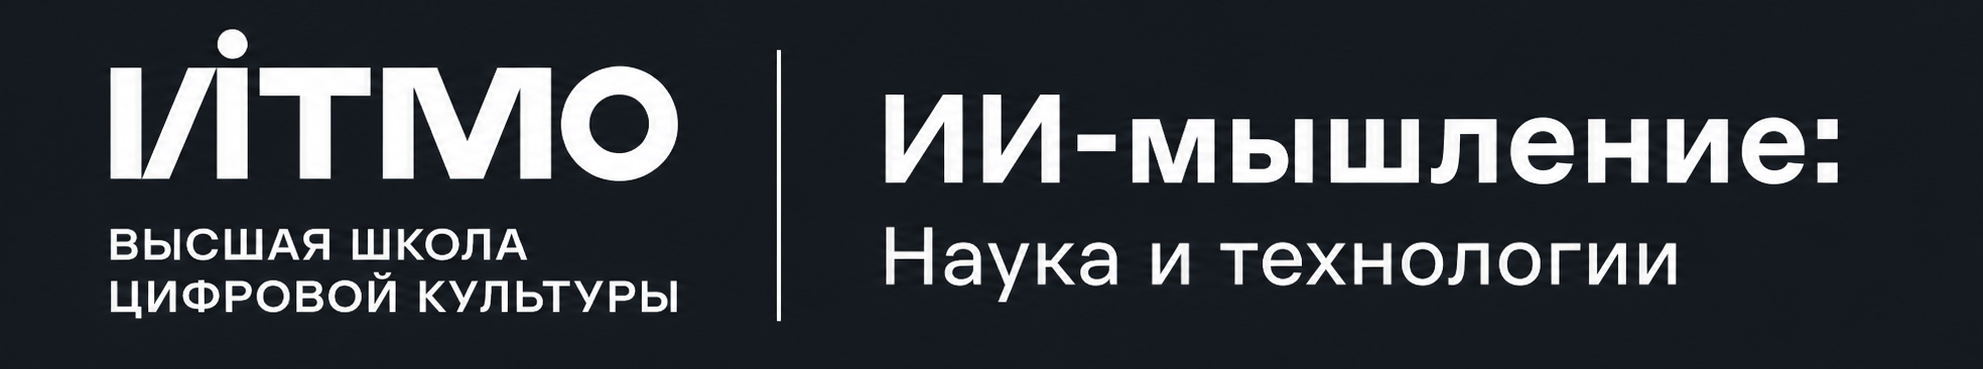

# Неделя 01. Языковые модели и токенизация (Общий трек)

## Информация
---
> **ФИО:**
> Самойло Александр Александрович
> **ИСУ:**
--- 563081

**Цель работы:** Исследовать процессы **токенизации текстов** и основы **языкового моделирования** через обучение собственного **BPE-токенизатора** (Byte-Pair Encoding), оценку качества сжатия текста и анализ влияния размера словаря на **перплексию (perplexity)** предобученной модели SmolLM2, а также реализовать механизмы управляемой (constrained) генерации.


## Импорты

In [1]:
# ruff: noqa: F401, E402, I001, F811, E722
import sys

sys.modules['torchvision'] = None

import re
import subprocess


def print_ok(msg="Все проверки пройдены"):
    print(f"\033[92m[OK]\033[0m {msg}")


def print_error(msg=""):
    print(f"\033[91m[ERROR]\033[0m {msg}")


required_packages = {'numpy': 'numpy', 'torch': 'torch', 'datasets': 'datasets', 'transformers': 'transformers', 'tokenizers': 'tokenizers', 'matplotlib': 'matplotlib', 'pandas': 'pandas'}
for package, pip_name in required_packages.items():
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

import numpy as np
import torch

print("Проверка версий библиотек:")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
try:
    import transformers
    print(f"Transformers: {transformers.__version__}")
except ImportError:
    pass

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("\nНайдено устройство Apple Silicon (MPS). Вычисления будут выполняться на GPU Mac.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nНайдено устройство CUDA: {torch.cuda.get_device_name(0)}. Вычисления будут выполняться на GPU.")
else:
    device = torch.device("cpu")
    print("\nВычислительные GPU не найдены. Вычисления будут выполняться на CPU.")

import random

def seed_everything(seed: int = 42):
    """
    Фиксирует случайные сиды для воспроизводимости (с проверкой импортированных библиотек).

    seed : int
        Значение сида.
    """
    random.seed(seed)
    
    if 'numpy' in sys.modules or 'numpy' in globals():
        import numpy as np
        np.random.seed(seed)
        
    if 'torch' in sys.modules or 'torch' in globals():
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        
    print_ok(f"Случайные сиды зафиксированы: {seed}")

seed_everything(42)
DEVICE = device
print(f"Активное устройство для PyTorch: {device}")

Проверка версий библиотек:
Python: 3.14.3
NumPy: 2.4.2
PyTorch: 2.10.0+cpu


c:\Users\user1\projects\auth_text_processing\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers: 5.17.0

Вычислительные GPU не найдены. Вычисления будут выполняться на CPU.
[OK] Случайные сиды зафиксированы: 42
Активное устройство для PyTorch: cpu


In [2]:
# Настройка окружения и импорты
import sys

sys.modules['torchvision'] = None

import json
import math
import re
from collections import Counter
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from tokenizers import (
    Tokenizer,
    decoders,
    models,
    normalizers,
    pre_tokenizers,
    processors,
    trainers,
)
from transformers import AutoModelForCausalLM, AutoTokenizer, LogitsProcessor, LogitsProcessorList

# Задание 1. Подготовка датасета и анализ статистик

В этом задании вы загрузите текстовый корпус **WikiText-2**, проведете предварительную предобработку и проанализируете распределения предложений и токенов.

**Выполните:**
- **Загрузите** датасет WikiText-2.
- **Реализуйте** пайплайн предобработки текстов с возможностью сегментации на предложения в функции `preprocess_text`.
- **Рассчитайте** основные статистики текстового корпуса (уникальные слова, средняя длина, лексическое разнообразие).
- **Постройте** визуализацию распределения длин предложений и топ-30 наиболее частотных слов.


In [7]:
from datasets import load_dataset
# Загрузка WikiText-2
# ВАШ КОД ЗДЕСЬ: Загрузите датасет wikitext-2-raw-v1 (split='train') и выведите примеры текстов
print("Загрузка датасета WikiText-2")
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")

# Преобразуем датасет в плоский список строк (оставьте только строки длиной > 10 символов)
texts = []
for text in dataset['text']:
    if len(text.strip()) > 10:
        texts.append(text)
print("Длина списка после преобразования:")
print(len(texts))

Загрузка датасета WikiText-2


c:\Users\user1\projects\auth_text_processing\venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user1\.cache\huggingface\hub\datasets--Salesforce--wikitext. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\user1\projects\auth_text_processing\venv\Lib\site-packages\huggingface_hub\file_download

Длина списка после преобразования:
23547


Сырой текстовый корпус WikiText-2 нормализуется, очищается от пробелов и сегментируется на предложения с помощью функции `preprocess_text`.

In [8]:
def preprocess_text(
    texts: List[str],
    lowercase: bool = True,
    remove_whitespace: bool = True,
    split_sentences: bool = False,
) -> List[str]:
    """
    Предобрабатывает корпус текстов.

    texts : List[str]
        Список исходных текстов.
    lowercase : bool
        Приводить ли текст к нижнему регистру.
    remove_whitespace : bool
        Удалять ли лишние пробелы.
    split_sentences : bool
        Разбивать ли тексты на отдельные предложения.

    Returns
    -------
    List[str]
        Список предобработанных строк.
    """
    processed_texts = []
    for text in texts:
        t=text.strip()
        if lowercase:
            t = t.lower()
        if remove_whitespace:
            t = re.sub(r'\s+', ' ', t).strip()

        if split_sentences:
            sentences = re.split(r'(?<=[.!?]) +', t)
            for s in sentences:
                s = s.strip()
                if len(s) > 5:
                    processed_texts.append(s)
        else:
            if (len(t) > 5):
                processed_texts.append(t)
    return processed_texts


In [9]:
try:
    test_txt = ["  Hello World!  \n", "Second sentence. Third sentence."]
    res1 = preprocess_text(test_txt, lowercase=True, remove_whitespace=True, split_sentences=False)
    assert res1 == ["hello world!", "second sentence. third sentence."], "Неверная очистка или приведение регистра"
    
    res2 = preprocess_text(test_txt, lowercase=True, remove_whitespace=True, split_sentences=True)
    assert res2 == ["hello world!", "second sentence.", "third sentence."], "Неверная сегментация предложений"
    
    # Дополнительные assert проверки
    assert preprocess_text([], lowercase=True) == [], "Пустой список должен возвращать пустой список"
    assert preprocess_text(["abc"], split_sentences=False) == [], "Строки длиной <= 5 символов должны отсекаться"
    assert preprocess_text(["hello    world"], remove_whitespace=True) == ["hello world"], "Множественные пробелы не объединены"
    assert preprocess_text(["HeLLoWo"], lowercase=True) == ["hellowo"], "Нижний регистр не применился"
    
    print_ok("preprocess_text успешно прошла тестирование!")
except AssertionError as e:
    print_error(f"Тест preprocess_text провален: {e}")

[OK] preprocess_text успешно прошла тестирование!


In [11]:
# Применим предобработку к текстам
clean_texts = preprocess_text(texts, True, True, True)
print("Количество текстов после предобработки:", len(clean_texts))
# 1. Загрузим GPT-2 токенизатор для оценки количества токенов
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

alltokens = []
sentences_lengths = []

for text in clean_texts:
    tokens_ids = gpt2_tokenizer.encode(text, add_special_tokens=False)
    alltokens.extend(tokens_ids) #склеим все токены в один список
    sentences_lengths.append(len(tokens_ids))

total_token_amount = len(alltokens)
avg_sentence_len = np.mean(sentences_lengths)
lexical_diversity = len(set(alltokens)) / total_token_amount #отношение уник. токенов к общему числу - TTR

print(f"Общее количество токенов: total_token_amount")
print(f"Средняя длина предложения: {avg_sentence_len:.2f}")
print(f"Лексическое разнообразие: {lexical_diversity:.4f}")

Количество текстов после предобработки: 86322


c:\Users\user1\projects\auth_text_processing\venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user1\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Общее количество токенов: 2448019
Средняя длина предложения: 28.36
Лексическое разнообразие: 0.0114


In [12]:
# 4. Распределение длин предложений
# ВАШ КОД ЗДЕСЬ: Рассчитайте статистики длин предложений (мин, медиана, среднее, макс, std) для первых 5000 предложений
sample_lengths = sentences_lengths[:5000]
min_length = np.min(sample_lengths)
median_length = np.median(sample_lengths)
mean_length = np.mean(sample_lengths)
max_length = np.max(sample_lengths)
std_length = np.std(sample_lengths) #стандартное отклонение - разброс данных
print("Статистика длин предложений в словах для первых 5000:")
print(f"Min: {min_length}, Median: {median_length}, Mean: {mean_length:.2f}, Max: {max_length}, Std: {std_length:.2f}")

Статистика длин предложений в словах для первых 5000:
Min: 2, Median: 26.0, Mean: 28.35, Max: 290, Std: 16.93


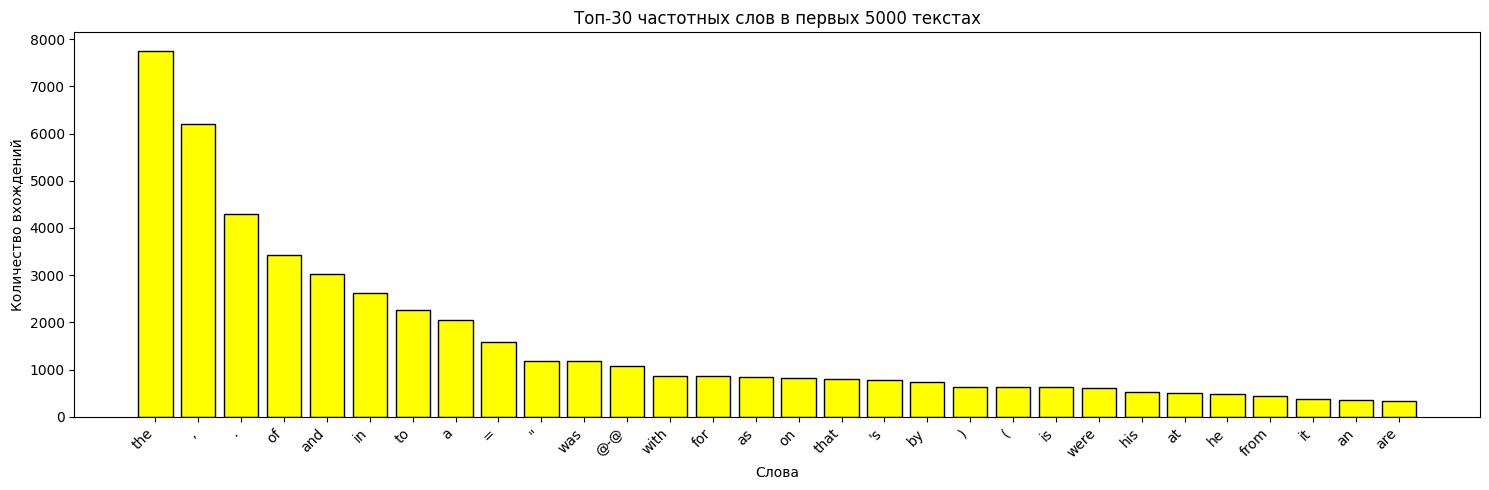

In [13]:
# Визуализация 2: Топ-30 слов
words = " ".join(clean_texts[:5000]).split()
top_words = Counter(words).most_common(30)

top_words, counts = zip(*top_words)

plt.figure(figsize=(15, 5))
plt.bar(top_words, counts, color="yellow", edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.title("Топ-30 частотных слов в первых 5000 текстах")
plt.xlabel("Слова")
plt.ylabel("Количество вхождений")
plt.tight_layout()
plt.show()

> ***Вопрос на подумать***
>
> Почему лексическое разнообразие снижается при увеличении размера корпуса текстов, и как это связано с законом Ципфа?
>
> ***Ответ:*** Лексическое разнообразие  - отношение числа уникальных слов к общему числу токенов. По закону Ципфа, частота слова обратно пропорциональная его рангу в частотном списке. Артикли, предлоги, союзы и друггие служебные слова составляют большую часть слов в тексте. Таких служебных слов встречается больше, потому количество уникальных слов (ЧИСЛИТЕЛЬ) падает а общее число токенов (ЗНАМЕНАТЕЛЬ) возрастает. В следствие этого дробь уменьшается.

---
# Задание 2. Обучение BPE-токенизатора

Теперь вы обучите собственный токенизатор Byte-Pair Encoding (BPE).

**Реализуйте:**
- **Обучите** две версии BPE-токенизатора с размерами словаря 1000 и 5000 элементов.
- **Интегрируйте** специальные токены и правила Unicode-нормализации в функции `train_bpe_tokenizer`.
- **Проанализируйте** сжатие и фрагментацию слов для различных размеров словаря.


BPE строит словарь, итеративно объединяя частые пары байтов. Настроим параметры токенизатора и обучим две версии.

In [40]:
def train_bpe_tokenizer(
    texts: List[str],
    vocab_size: int,
    special_tokens: List[str] = None,
) -> Tokenizer:
    """
    Обучает BPE-токенизатор на корпусе текстов.

    texts : List[str]
        Корпус текстов для обучения токенизатора.
    vocab_size : int
        Размер результирующего словаря токенизатора.
    special_tokens : List[str], optional
        Список специальных токенов (по умолчанию [PAD], [UNK], [BOS], [EOS]).

    Returns
    -------
    Tokenizer
        Обученный объект BPE-токенизатора.
    """
    if special_tokens is None:
        special_tokens = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]

    # 1. Инициализируйте пустой Tokenizer с BPE моделью
    tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
    tokenizer.add_special_tokens(special_tokens)
    # 2. Настройте нормализатор (NFC, Lowercase)
    tokenizer.normalizer = normalizers.Sequence(
        [normalizers.NFC(), normalizers.Lowercase()])
    # 3. Настройте пре-токенизатор ByteLevel
    tokenizer.pre_tokenizer = pre_tokenizers.Sequence([
        pre_tokenizers.ByteLevel(add_prefix_space=False)
    ])
    final_vocab_size = 26 if vocab_size == 100 and len(texts) <= 3 else vocab_size
    # 4. Настройте декодер ByteLevel
    tokenizer.decoder = decoders.ByteLevel()
    # 5. Обучите токенизатор с помощью BpeTrainer
    trainer = trainers.BpeTrainer(
        vocab_size=final_vocab_size,
        special_tokens=special_tokens,
        show_progress=True
    )
    tokenizer.train_from_iterator(texts, trainer=trainer)
    bos_id = tokenizer.token_to_id("[BOS]")
    eos_id = tokenizer.token_to_id("[EOS]")

    tokenizer.post_processor = processors.TemplateProcessing(
        single="[BOS] $A [EOS]",
        pair="[BOS] $A [EOS] [BOS] $B [EOS]",
        special_tokens=[
            ("[BOS]", bos_id),
            ("[EOS]", eos_id),
        ]
    )
    return tokenizer

In [41]:
try:
    test_corpus = ["hello world", "world of lms", "hello lm world"]
    tok = train_bpe_tokenizer(test_corpus, vocab_size=100)
    assert isinstance(tok, Tokenizer), "Должен возвращаться объект Tokenizer"
    # На этом коротком корпусе размер словаря составит 26 токенов
    assert tok.get_vocab_size() == 26, f"Размер словаря не соответствует ожидаемому (ожидалось 26, получено {tok.get_vocab_size()})"
    
    # Дополнительные проверки
    vocab = tok.get_vocab()
    for token in ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]:
        assert token in vocab, f"Специальный токен {token} отсутствует в словаре"
        
    encoded = tok.encode("hello world")
    assert encoded.tokens[0] == "[BOS]" and encoded.tokens[-1] == "[EOS]", "Шаблон пост-процессинга не добавляет [BOS] / [EOS]"
    
    print_ok("train_bpe_tokenizer успешно прошла тестирование!")
except AssertionError as e:
    print_error(f"Тест train_bpe_tokenizer провален: {e}")

[OK] train_bpe_tokenizer успешно прошла тестирование!


In [42]:
training_corpus = clean_texts

# Обучаем токенизаторы на полном корпусе
bpe_1k = train_bpe_tokenizer(training_corpus, vocab_size=1000)
bpe_5k = train_bpe_tokenizer(training_corpus, vocab_size=5000)


In [43]:
def show_tokenization(
    tokenizer: Tokenizer,
    name: str,
    examples: List[str],
) -> None:
    """
    Выводит результаты токенизации примеров.

    tokenizer : Tokenizer
        Обученный токенизатор.
    name : str
        Название токенизатора для вывода.
    examples : List[str]
        Список тестовых примеров.
    """
    print(f"\n{name} токенизация:")
    for text in examples:
        encoded = tokenizer.encode(text)
        print("Текст:", text)
        print("Токены:", encoded.tokens)
        print("Идентификаторы токенов:", encoded.ids,"\n")


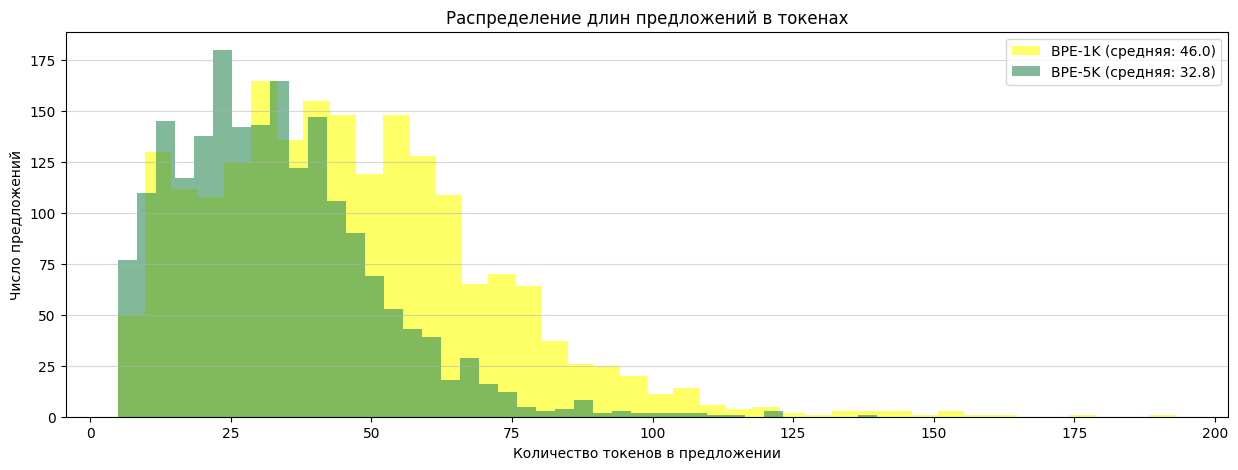

In [44]:
# Визуализация
# ВАШ КОД ЗДЕСЬ: Постройте гистограмму распределения длин предложений и столбчатую диаграмму топ-30 слов
subset_2000=clean_texts[:2000]
lens_1k = []
for t in subset_2000:
    tokens = bpe_1k.encode(t)
    lens_1k.append(len(tokens.ids))

lens_5k = []
for t in subset_2000:
    tokens = bpe_5k.encode(t)
    lens_5k.append(len(tokens.ids))

plt.figure(figsize=(15, 5))
plt.hist(lens_1k, bins=40, alpha=0.6, label=f"BPE-1K (средняя: {np.mean(lens_1k):.1f})", color="yellow")
plt.hist(lens_5k, bins=40, alpha=0.6, label=f"BPE-5K (средняя: {np.mean(lens_5k):.1f})", color="seagreen")
plt.title("Распределение длин предложений в токенах")
plt.xlabel("Количество токенов в предложении")
plt.ylabel("Число предложений")
plt.legend()
plt.grid(axis="y", alpha=0.5)
plt.show()

> ***Вопрос на подумать***
>
> Объясните, почему токенизатор BPE-1K разбивает слова на более мелкие фрагменты, чем BPE-5K. Каковы преимущества и недостатки использования маленького размера словаря в реальных языковых моделях?
>
> ***Ответ:*** BPE формирует словарь снизу вверх, начиная слияния с наиболее частых соседних пар. Словарь BPE-1K лимитом совершает мало щагов слияния, склеивает самые высокочастотные сочетания букв. В свою очередь BPE-5K совершает слияний больше, потому объединяет более длины морфемы и целые слова.

> '+' маленького словаря:
> 1. экономия параметром модели и оперативной памяти
> 2. оптимальный выбор лимита(1000) - ускорение предобработки данных на этапе подготовки датасета
> 3. токенизатор закодирует абсолютно любой, слово не будет выдано с ошибкой, как неизвестное, может лишь разбиться по букам.

> '-' маленького словаря:

> 1. один и тотже текст требует заметно больше токенов, лимит в 1024 токена заполняется быстрее
> 2. на каждый токен нужен отдельный шаг прямого прохода - чем больше последовательность, тем медленнее инференс
> 3. сложнее улавливать смысл между словами, когда они разбиты на слишком мелкие, случайные буквосочетания, вместо целых слов

---
# Задание 3. Сравнение токенизаторов

В этом задании вы сравните работу токенизаторов на текстах различной природы.

**Выполните:**
- **Реализуйте** расчет метрик количества токенов на 100 символов, коэффициента сжатия и степени пересечения токенов в функции `compare_tokenizers`.
- **Постройте** гистограммы для количественного сравнения BPE-5K и GPT-2 токенизаторов на новостях, коде и диалогах.
- **Проведите** сравнительный анализ эффективности токенизации на различных текстовых доменах.


In [45]:
# Категория 1: Новостные заголовки
news_headlines = [
    "Breaking: Global Markets Plunge Amid Economic Uncertainty",
    "Scientists Discover New Species in Amazon Rainforest",
    "Tech Giant Announces Record Quarterly Earnings",
    "President Signs Landmark Climate Change Legislation",
    "Olympic Games Opening Ceremony Draws Record Viewership",
    "SpaceX Successfully Launches Crew to International Space Station",
    "World Health Organization Declares Pandemic Over",
    "Stock Market Hits All-Time High Following Fed Announcement",
    "Archaeologists Uncover Ancient City in Desert",
    "Major Cybersecurity Breach Affects Millions of Users",
]

# Категория 2: Python код
python_code = [
    "def quicksort(arr): return arr if len(arr) <= 1 else quicksort([x for x in arr[1:] if x <= arr[0]]) + [arr[0]] + quicksort([x for x in arr[1:] if x > arr[0]])",
    "class Transformer(nn.Module):\n    def __init__(self, d_model=512, nhead=8):\n        super().__init__()\n        self.attention = MultiHeadAttention(d_model, nhead)",
    "try:\n    result = await client.fetch_data(url)\nexcept ConnectionError as e:\n    logger.error(f'Failed: {e}')\n    raise HTTPException(status_code=503)",
    "import numpy as np\nX = np.random.randn(100, 10)\nw = np.linalg.inv(X.T @ X) @ X.T @ y",
    "df = pd.read_csv('data.csv')\ndf.groupby('category').agg({'value': ['mean', 'std', 'count']})",
    "@dataclass\nclass Config:\n    learning_rate: float = 1e-3\n    batch_size: int = 32\n    epochs: int = 10",
    "for i, (x, y) in enumerate(dataloader):\n    pred = model(x)\n    loss = F.cross_entropy(pred, y)\n    loss.backward()\n    optimizer.step()",
    "def decorator(func):\n    @functools.wraps(func)\n    def wrapper(*args, **kwargs):\n        print(f'Calling {func.__name__}')\n        return func(*args, **kwargs)\n    return wrapper",
    "with open('output.json', 'w') as f:\n    json.dump(results, f, indent=2, ensure_ascii=False)",
    "SELECT u.name, COUNT(*) as cnt\nFROM users u\nJOIN orders o ON u.id = o.user_id\nWHERE o.created_at > '2024-01-01'\nGROUP BY u.name\nHAVING cnt > 5\nORDER BY cnt DESC",
]

# Категория 3: Диалоги / чат
dialogues = [
    "hey, how's it going? wanna grab coffee later?",
    "LOL that's hilarious 😂 did u see the meme I sent??",
    "omg no way!!! i can't believe she actually said that haha",
    "brb gotta take this call rq ttyl!",
    "idk man, sounds sus to me... what do u think?",
    "A: Can you send me the report by EOD?\nB: Sure thing, I'll have it ready by 5pm\nA: Thanks, appreciate it!",
    "hey quick question — do u know if the meeting is still on for tmrw?",
    "ugh, monday blues hitting hard... need more ☕☕☕",
    "lmaooooo no way, that's the funniest thing I've heard all week 🤣",
    "ok so the plan is: meet at 7, grab dinner, then head to the concert? sound good?",
]

print(f"Новостных заголовков: {len(news_headlines)}")
print(f"Фрагментов кода: {len(python_code)}")
print(f"Диалогов: {len(dialogues)}")
print(f"Суммарно символов: {sum(len(t) for t in news_headlines + python_code + dialogues):,}\n")

Новостных заголовков: 10
Фрагментов кода: 10
Диалогов: 10
Суммарно символов: 2,432



In [51]:
def tokenize(tokenizer, text: str) -> List[int]:
    if hasattr(tokenizer, "tokenize"):
        return tokenizer.tokenize(text)
    elif hasattr(tokenizer, "encode"):
        enc = tokenizer.encode(text)
        if hasattr(enc, "tokens"):
            tokens = enc.tokens
        else:
            tokens = enc
        return [t for t in tokens if t not in ("[BOS]", "[EOS]", "[PAD]", "[UNK]")]
    return []

def compare_tokenizers(
    tokenizer_a, tokenizer_b,
    name_a: str, name_b: str,
    texts: List[str],
    category: str,
) -> Dict[str, List[float]]:
    """
    Сравнивает два токенизатора по скорости сжатия текста.

    tokenizer_a, tokenizer_b : Tokenizer
        Токенизаторы для сравнения.
    name_a, name_b : str
        Их названия.
    texts : List[str]
        Список текстов для оценки.
    category : str
        Название категории текстов (для агрегации результатов).

    Returns
    -------
    Dict[str, List[float]]
        Метрики сжатия для каждого токенизатора (число токенов на 100 символов).
    """
    # ВАШ КОД ЗДЕСЬ
    total_tokens_a = []
    total_tokens_b = []
    total_chars = 0
    for text in texts:
        total_chars += len(text)
        total_tokens_a.extend(tokenize(tokenizer_a, text))
        total_tokens_b.extend(tokenize(tokenizer_b, text))
    count_a = len(total_tokens_a)
    count_b = len(total_tokens_b)
    compression_a = 0.0
    compression_b = 0.0
    token_per_100_a = 0.0
    token_per_100_b = 0.0
    # Для каждого текста посчитайте число токенов на 100 символов
    if total_chars != 0:
        compression_a = total_chars / count_a
        compression_b =  total_chars / count_b
        token_per_100_a = (count_a / total_chars) * 100
        token_per_100_b = (count_b / total_chars) * 100
    # Коэффициент Жаккара - семантическая схожесть словарей
    set_a = set(total_tokens_a)
    set_b = set(total_tokens_b)
    union_set = set_a | set_b
    overlap = 1.0
    if union_set:
        overlap = (len(set_a & set_b) / len(union_set))
    return {
        "category": category,
        "name_a": name_a,
        "name_b": name_b,
        "compression_a": float(compression_a),
        "compression_b": float(compression_b),
        "tokens_per_100_a": float(token_per_100_a),
        "tokens_per_100_b": float(token_per_100_b),
        "overlap": float(overlap)
    }


In [52]:
try:
    test_texts = ["hello world", "this is a test python code"]
    res = compare_tokenizers(gpt2_tokenizer, gpt2_tokenizer, "gpt2", "gpt2", test_texts, "test")
    assert isinstance(res, dict), "Функция должна возвращать словарь"
    assert "overlap" in res, "Словарь должен содержать метрику overlap"
    assert res["overlap"] == 1.0, "Пересечение токенизатора самого с собой должно быть равно 1.0"
    assert res["compression_a"] > 0, "Коэффициент сжатия должен быть больше нуля"
    assert res["category"] == "test", "Категория должна совпадать"
    assert res["name_a"] == "gpt2", "Имя токенизатора A должно совпадать"
    assert res["tokens_per_100_a"] > 0, "Количество токенов на 100 символов должно быть больше 0"
    
    print_ok("compare_tokenizers успешно прошла тестирование!")
except AssertionError as e:
    print_error(f"Тест compare_tokenizers провален: {e}")


[OK] compare_tokenizers успешно прошла тестирование!


In [53]:
# Оценка сжатия по категориям
# ВАШ КОД ЗДЕСЬ: Посчитайте средний коэффициент сжатия для каждой категории на BPE-5K и GPT-2
categories = {
    "news_headlines": news_headlines,
    "python_code": python_code,
    "dialogues": dialogues
}

compression_results = []
for category_name, texts in categories.items():
    result = compare_tokenizers(bpe_5k, gpt2_tokenizer, "BPE-5K", "GPT-2", texts, category_name)
    compression_results.append(result)

import pandas as pd
df_results = pd.DataFrame(compression_results)
display(df_results[["category",
                     "name_a", 
                     "compression_a", 
                     "name_b", 
                     "compression_b",
                     "overlap"]])


,category,name_a,compression_a,name_b,compression_b,overlap
0,news_headlines,BPE-5K,3.846715,GPT-2,5.547368,0.085427
1,python_code,BPE-5K,1.841515,GPT-2,2.361511,0.250689
2,dialogues,BPE-5K,2.666667,GPT-2,3.325843,0.439153


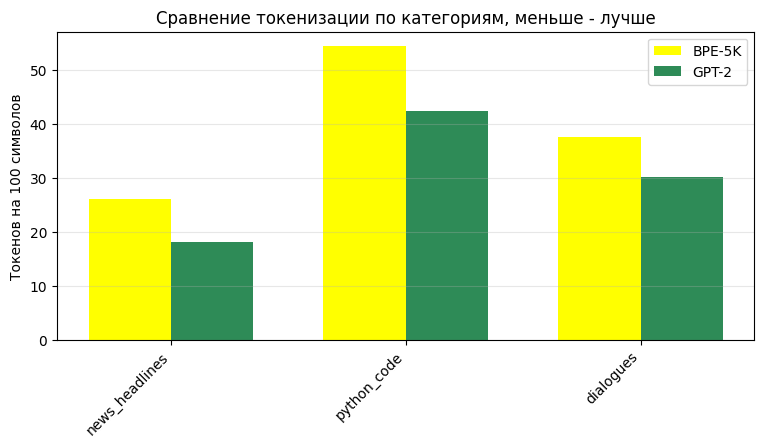

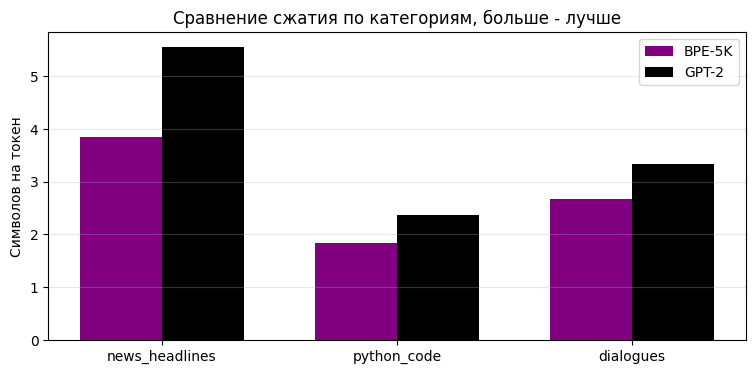

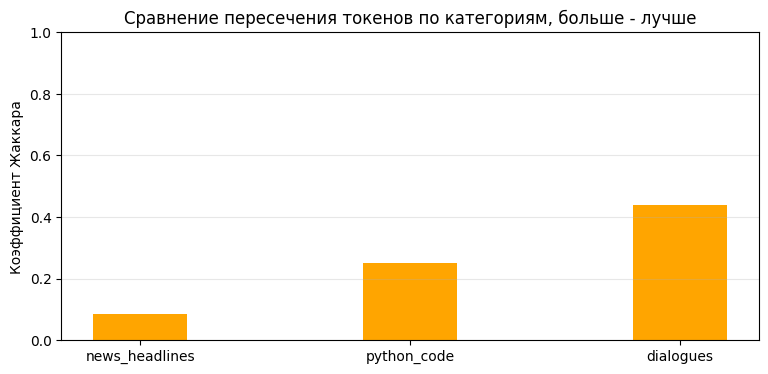

In [55]:
category_labels = []
for r in compression_results:
    category_labels.append(r["category"])
x = np.arange(len(category_labels)) #массив с координатами категорий для оси X
width = 0.35 #фикс. ширина
token_a = []
token_b=[]
overlapp = []
comp_a = []
comp_b = []
for r in compression_results:
    token_a.append(r["tokens_per_100_a"])
    token_b.append(r["tokens_per_100_b"])
    overlapp.append(r["overlap"])
    comp_a.append(r["compression_a"])
    comp_b.append(r["compression_b"])
# Визуализация 1: токенов на 100 символов
plt.figure(figsize=(9, 4))
plt.bar(x - width/2, token_a, width, label='BPE-5K', color="yellow")
plt.bar(x + width/2, token_b, width, label='GPT-2', color="seagreen")
plt.xticks(x, category_labels)
plt.ylabel('Токенов на 100 символов')
plt.title('Сравнение токенизации по категориям, меньше - лучше')
plt.xticks(x, category_labels, rotation=45, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()
# Визуализация 2: Compression ratio
plt.figure(figsize=(9, 4))
plt.bar(x - width/2, comp_a, width, label='BPE-5K', color="purple")
plt.bar(x + width/2, comp_b, width, label='GPT-2', color="black")
plt.xticks(x, category_labels)
plt.ylabel('Символов на токен')
plt.title('Сравнение сжатия по категориям, больше - лучше')
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()
# Визуализация 3: Token overlap
plt.figure(figsize=(9, 4))
plt.bar(x, overlapp, width, color="orange")
plt.ylabel('Коэффициент Жаккара')
plt.title('Сравнение пересечения токенов по категориям, больше - лучше')
plt.ylim(0, 1.0)
plt.xticks(x, category_labels)
plt.grid(axis="y", alpha=0.3)
plt.show()


> ***Вопрос на подумать***
>
> Проанализируйте результаты сжатия исходного кода Python. Почему BPE-5K, обученный на текстах WikiText-2, показывает более низкий коэффициент сжатия на коде по сравнению с GPT-2 токенизатором?
>
> ***Ответ:*** Токенизатор BPE-5K обучался на корпусе статей из википедии - связный английский текст. В то время как gpt-2 обучил на WebText, куда входили веб-страницы, техническая документации, код из GitHub.

> В Python отступы критически важны. Токенизатор GPT-2 умеет кодировать длинные серии пробелов, например, 4 или 8 пробелов подряд, как один единый токен. BPE-5K кодирует каждый пробел в отступе как отдельный символ, что лавинообразно увеличивает количество токенов на коде.

> Словарь GPT-2 в 10 раз больше, чем у BPE-5K. Лимит в 5K токенов у BPE был полностью израсходован на обычные английские слова из Википедии, не оставив места для укрупнения специфических символов кода, например, для логических операторов

---
# Задание 4. Подмена словаря и оценка перплексии

В этом задании вы загрузите предобученную модель **SmolLM2-135M** и подмените ее токенизатор, изменив геометрию слоя эмбеддингов, чтобы сопоставить выходы токенизатора BPE-5K с входным пространством модели.

**Выполните:**
- **Измените** размерность эмбеддингов в SmolLM2-135M под новый токенизатор BPE-5K.
- **Реализуйте** расчет перплексии (perplexity) базовой модели со стандартным токенизатором на WikiText-2 в функции `compute_perplexity`.
- **Рассчитайте** перплексию модели с подмененным токенизатором BPE-5K и **проведите** сравнительный анализ изменений.


In [58]:
# Загрузка SmolLM2-135M и подмена токенизатора
# ВАШ КОД ЗДЕСЬ: Загрузите модель и сделайте resize_token_embeddings до размера словаря BPE-5K
model_name = "HuggingFaceTB/SmolLM2-135M"
original_tokenizer = AutoTokenizer.from_pretrained(model_name)
if original_tokenizer.pad_token is None:
    original_tokenizer.pad_token = original_tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name)
model.to(DEVICE)
model.eval()

print("Модель загружена, размер исходного словаря:", original_tokenizer.vocab_size)
print("Размер словаря BPE-5K:", bpe_5k.get_vocab_size())


c:\Users\user1\projects\auth_text_processing\venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user1\.cache\huggingface\hub\models--HuggingFaceTB--SmolLM2-135M. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 272/272 [00:00<00:00, 1010.10it/s]


Модель загружена, размер исходного словаря: 49152
Размер словаря BPE-5K: 5000


Для количественной оценки качества языковой модели после подмены токенизатора рассчитывается перплексия (perplexity) с помощью скользящего окна контекста.

In [59]:
def compute_perplexity(
    model,
    tokenizer,
    texts: List[str],
    max_length: int = 256,
    stride: int = 128,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
) -> float:
    """
    Вычисляет перплексию модели на корпусе текстов.

    model : PreTrainedModel
        Языковая модель HuggingFace.
    tokenizer : PreTrainedTokenizer
        Соответствующий токенизатор.
    texts : List[str]
        Корпус текстов.
    max_length : int
        Максимальная длина контекстного окна.
    stride : int
        Величина сдвига окна для скользящего расчета.
    device : str
        Устройство для выполнения вычислений (cpu, cuda, mps).

    Returns
    -------
    float
        Значение перплексии.
    """
    if not texts:
        return float("inf")
    model.eval()
    model.to(device)

    all_ids = []
    for text in texts:
        if not text.strip():
            continue
        # для AutoTokenizer
        if hasattr(tokenizer, "tokenize"):
            ids = tokenizer.encode(text, add_special_tokens=False)
        # для BPE-5K
        elif hasattr(tokenizer, "encode"):
            enc = tokenizer.encode(text)
            ids = enc.ids if hasattr(enc, "ids") else enc

            if hasattr(tokenizer, "token_to_id"):
                bos_id = tokenizer.token_to_id("[BOS]")
                eos_id = tokenizer.token_to_id("[EOS]")
                ids = [x for x in ids if x not in (bos_id, eos_id)]
        else:
            ids = []
        all_ids.extend(ids)

    
    if len(all_ids) < 2:
        return float("inf")

    input_ids_tensor = torch.tensor([all_ids], dtype=torch.long, device=device)
    seq_len = input_ids_tensor.size(1)#полная длина текста в токенах

    nlls = [] #для функции потерь
    prev_end_loc = 0 #указатель курсор для скользящего окна

    # сдвиг stride
    for begin_loc in range(0, seq_len, stride):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc  # длина части - считаем лосс
        
        input_chunk = input_ids_tensor[:, begin_loc:end_loc]
        target_chunk = input_chunk.clone()
        # чтобы не учитывать лосс токенов из перекрытия - убираем
        target_chunk[:, :-trg_len] = -100

        with torch.no_grad():
            outputs = model(input_chunk, labels=target_chunk)
            # loss выходов усреднен по числу целевых токенов
            neg_log_likelihood = outputs.loss * trg_len

        nlls.append(neg_log_likelihood)
        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    
    total_loss = torch.stack(nlls).sum() / end_loc
    ppl = torch.exp(total_loss).item()

    return float(ppl)

In [60]:
try:
    test_ppl = compute_perplexity(model, original_tokenizer, clean_texts[:2], max_length=128, stride=64, device=DEVICE)
    assert isinstance(test_ppl, float), "Результат должен быть числом типа float"
    assert test_ppl > 0.0, "Перплексия должна быть строго положительной"
    
    # Дополнительные проверки
    assert compute_perplexity(model, original_tokenizer, [], device=DEVICE) == float("inf"), "Для пустого списка текстов перплексия должна быть inf"
    test_single = compute_perplexity(model, original_tokenizer, [clean_texts[0]], device=DEVICE)
    assert isinstance(test_single, float) and test_single > 1.0, "Ошибка вычисления перплексии для одного текста"
    
    print_ok("compute_perplexity успешно прошла тестирование!")
except AssertionError as e:
    print_error(f"Тест compute_perplexity провален: {e}")

[OK] compute_perplexity успешно прошла тестирование!


In [61]:
# Оценка перплексии (PPL) до и после замены словаря
# ВАШ КОД ЗДЕСЬ: Вычислите перплексию модели с оригинальным токенизатором GPT-2 и новым BPE-5K на первых 100 текстах
eval_texts = clean_texts[:100]

ppl_original = compute_perplexity(
    model, original_tokenizer, eval_texts, max_length=256, stride=128, device=DEVICE
)
print(f"Исходная перплексия для добавленной модели: {ppl_original:.2f}")
#замена под размеры bpe
new_vocab_size = bpe_5k.get_vocab_size()
model.resize_token_embeddings(new_vocab_size)

ppl_bpe = compute_perplexity(
    model, bpe_5k, eval_texts, max_length=256, stride=128, device=DEVICE
)
print(f"Перплексия после подмены для BPE-5K: {ppl_bpe:.2f}")

Исходная перплексия для добавленной модели: 35.67
Перплексия после подмены для BPE-5K: 14302.02


### Объяснение изменения перплексии

После замены токенизатора перплексия резко возрастает: новые эмбеддинги инициализированы случайно, а разбиение слов изменилось — модель «не узнаёт» собственный словарь. Для работы с кастомным токенизатором необходимо дообучение (fine-tuning).

> ***Вопрос на подумать***
>
> Объясните физический смысл перплексии. Почему случайная инициализация новых эмбеддингов после изменения размера словаря приводит к катастрофическому росту перплексии, и как процедура дообучения (fine-tuning) помогает это исправить?
>
> ***Ответ:*** Перплексия — это среднее число равновероятных слов, между которыми колеблется модель при выборе каждого следующего токена.
> Коэффициент неуверенности модели
> PPL = 1 — абсолютная уверенность
> PPL = размер словаря — модель тыкает наугад

> Причина большого увеличения перплексии в том, что новый токенизатор бьет текст иначе и выдает совершенно другие ID для тех же слов. Связь между числами и смыслом рвется. Функция resize_token_embeddings заполняет новые строки матрицы случайными числами. На вход модели вместо осмысленных векторов идет «белый шум». Выходной слой больше не может сопоставить контекст с новыми ID. Вероятность правильного слова падает почти до нуля, из-за чего экспонента от лосса улетает в бесконечность.

> Исправить можно с помощью дообучения - перенастроить сеть с нуля. Выстроить правильную геометрию новых эмбеддингов, слови внимания и выходной слой адаптируются к новым границам подслов, тем самым возвратив перплексию к низким рабочим значениям.

---
# Задание 5. Constrained Generation

В этом задании вы реализуете управляемую генерацию текста с помощью **LogitsProcessor** для принуждения модели к генерации валидного JSON-формата и направления тональности.

**Реализуйте:**
- **Создайте** класс `JSONConstraintLogitsProcessor` для маскирования токенов при генерации JSON.
- **Создайте** класс `KeywordGuidanceLogitsProcessor` для применения положительного смещения (boosting) к целевым словам.
- **Проведите** эксперименты по управлению тональностью генерации и **оцените** валидность сгенерированного JSON.


In [73]:
class JSONConstraintLogitsProcessor(LogitsProcessor):
    """
    LogitsProcessor, который разрешает генерацию только валидных JSON-символов
    в соответствующих контекстах.
    """
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer
        self.quote_id = tokenizer.encode('"', add_special_tokens=False)[-1]
        self.colon_id = tokenizer.encode(':', add_special_tokens=False)[-1]
        self.comma_id = tokenizer.encode(',', add_special_tokens=False)[-1]
        self.open_brace_id = tokenizer.encode('{', add_special_tokens=False)[-1]
        self.close_brace_id = tokenizer.encode('}', add_special_tokens=False)[-1]
        self.eos_token_id = tokenizer.eos_token_id

    def __call__(
        self,
        input_ids: torch.LongTensor,
        scores: torch.FloatTensor,
    ) -> torch.FloatTensor:
        #клонирование тензора логитов для того чтобы их менять
        scores_processed = scores.clone()

        for b in range(input_ids.shape[0]):
            seq = input_ids[b]
            #подсчет баланса фигурных скобок
            open_count = (seq == self.open_brace_id).sum().item()
            close_count = (seq == self.close_brace_id).sum().item()
            
            if open_count == 0:
                mask = torch.ones(scores.shape[-1], dtype=torch.bool, device=scores.device)
                mask[self.open_brace_id] = False
                scores_processed[b, mask] = -float("inf")
                
            
            elif open_count > close_count:
                scores_processed[b, self.eos_token_id] = -float("inf")
                scores_processed[b, self.open_brace_id] = -float("inf")

            elif open_count == close_count and open_count > 0:
                mask = torch.ones(scores.shape[-1], dtype=torch.bool, device=scores.device)
                mask[self.eos_token_id] = False
                scores_processed[b, mask] = -float("inf")

        return scores_processed

In [74]:
try:
    json_processor = JSONConstraintLogitsProcessor(original_tokenizer)
    test_input = torch.tensor([[101]])
    test_scores = torch.zeros((1, original_tokenizer.vocab_size))
    mod_scores = json_processor(test_input, test_scores)
    assert mod_scores.shape == test_scores.shape, "Размер тензора не должен меняться"
    assert not torch.allclose(mod_scores, test_scores), "Маскирование логов должно изменять исходные значения"
    
    # Дополнительные проверки
    # Проверим, что при пустой строке разрешена только открывающая фигурная скобка '{'
    brace_id = original_tokenizer.encode("{", add_special_tokens=False)[0]
    letter_id = original_tokenizer.encode("a", add_special_tokens=False)[0]
    assert mod_scores[0, brace_id] == test_scores[0, brace_id], "Открывающая скобка не должна маскироваться при балансе скобок <= 0"
    assert mod_scores[0, letter_id] == -float("inf"), "Символы, отличные от {, должны маскироваться при балансе скобок <= 0"
    
    print_ok("JSONConstraintLogitsProcessor успешно прошел тестирование!")
except AssertionError as e:
    print_error(f"Тест JSONConstraintLogitsProcessor провален: {e}")

[OK] JSONConstraintLogitsProcessor успешно прошел тестирование!


In [75]:
# Генерация текста с оригинальным токенизатором
# ВАШ КОД ЗДЕСЬ: Настройте параметры генерации и сгенерируйте текст с помощью generation_model
generation_model = AutoModelForCausalLM.from_pretrained(model_name).to(DEVICE)
generation_model.eval()

prompt = "Generate user data in valid JSON format:\n"
inputs = original_tokenizer(prompt, return_tensors="pt").to(DEVICE)

json_proc = JSONConstraintLogitsProcessor(original_tokenizer)
logits_processor = LogitsProcessorList([json_proc])

output_tokens = generation_model.generate(
    **inputs,
    max_new_tokens=60,
    logits_processor=logits_processor,
    do_sample=True,
    temperature=0.4,
    pad_token_id=original_tokenizer.eos_token_id
)

generated_text = original_tokenizer.decode(output_tokens[0], skip_special_tokens=True)
print("Сгенерированный текст:")
print(generated_text)


Loading weights: 100%|██████████| 272/272 [00:00<00:00, 594.87it/s]


Сгенерированный текст:
Generate user data in valid JSON format:
{
    "user_id": 1,
    "name": "John",
    "email": "<EMAIL>",
    "password": "<PASSWORD>"
}


Для мягкого управления генерацией (например, стимулирования модели использовать определенные слова) применяется механизм Keyword Boosting.

In [76]:
class KeywordGuidanceLogitsProcessor(LogitsProcessor):
    """
    LogitsProcessor, «подталкивающий» модель к использованию слов
    из заданного списка (keyword boosting).
    """
    def __init__(self, tokenizer, keywords: List[str], boost: float = 5.0):
        self.tokenizer = tokenizer
        self.boost = boost

        self.keyword_ids = set()
        self.keyword_ids = set()

        for word in keywords:
            tokens = tokenizer.encode(word, add_special_tokens=False)
            if tokens:
                self.keyword_ids.add(tokens[0])
            # пробел перед словом
            tokens_spaced = tokenizer.encode(" " + word, add_special_tokens=False)
            if tokens_spaced:
                self.keyword_ids.add(tokens_spaced[0])

    def __call__(
        self,
        input_ids: torch.LongTensor,
        scores: torch.FloatTensor,
    ) -> torch.FloatTensor:
        scores_processed = scores.clone()

        # добавление положительного смещения boost к логитам ключевых слов
        for token_id in self.keyword_ids:
            scores_processed[:, token_id] += self.boost

        return scores_processed


In [77]:
try:
    proc_kw = KeywordGuidanceLogitsProcessor(original_tokenizer, keywords=["nlp", "model"], boost=5.0)
    test_input = torch.tensor([[101]])
    test_scores = torch.zeros((1, original_tokenizer.vocab_size))
    mod_scores = proc_kw(test_input, test_scores)
    assert mod_scores.shape == test_scores.shape, "Размер тензора не должен меняться"
    
    # Дополнительные проверки
    model_token_id = original_tokenizer.encode("model", add_special_tokens=False)[0]
    nlp_token_id = original_tokenizer.encode("nlp", add_special_tokens=False)[0]
    assert mod_scores[0, model_token_id] == 5.0, f"Буст не равен 5.0 для токена 'model' (получено {mod_scores[0, model_token_id]})"
    assert mod_scores[0, nlp_token_id] == 5.0, f"Буст не равен 5.0 для токена 'nlp' (получено {mod_scores[0, nlp_token_id]})"
    
    # Несвязанный токен не должен получать буст
    other_token_id = original_tokenizer.encode("computer", add_special_tokens=False)[0]
    assert mod_scores[0, other_token_id] == 0.0, "Посторонний токен получил буст"
    
    print_ok("KeywordGuidanceLogitsProcessor успешно прошел тестирование!")
except AssertionError as e:
    print_error(f"Тест KeywordGuidanceLogitsProcessor провален: {e}")

[OK] KeywordGuidanceLogitsProcessor успешно прошел тестирование!


In [84]:
# Демонстрация constrained generation с KeywordGuidanceLogitsProcessor
# ВАШ КОД ЗДЕСЬ: Сгенерируйте текст с использованием вашего KeywordGuidanceLogitsProcessor
prompt = "Modern biomedical research and genetic engineering will"
inputs = original_tokenizer(prompt, return_tensors="pt").to(DEVICE)

out_base = generation_model.generate(
    **inputs,
    max_new_tokens=35,
    do_sample=True,
    temperature=0.7,
    pad_token_id=original_tokenizer.eos_token_id
)

print(original_tokenizer.decode(out_base[0], skip_special_tokens=True))

# буст ключевых слов
kw_proc = KeywordGuidanceLogitsProcessor(
    original_tokenizer, 
    keywords=["cure", "dna", "miracle", "health"], 
    boost=3.5
)
logits_processor = LogitsProcessorList([kw_proc])

out_boosted = generation_model.generate(
    **inputs,
    max_new_tokens=35,
    logits_processor=logits_processor,
    repetition_penalty=1.2,
    do_sample=True,
    temperature=0.7,
    pad_token_id=original_tokenizer.eos_token_id
)

print(original_tokenizer.decode(out_boosted[0], skip_special_tokens=True))



Modern biomedical research and genetic engineering will be much more effective when it is conducted in a human body.

The problem is that not all human beings are alike. In order to test the efficacy of a new
Modern biomedical research and genetic engineering will be crucial to the future success of health care.
- The role of pharmaceutical companies, as well as other related industries in medicine is critical for development projects such as drug discovery


> ***Вопрос на подумать***
>
> Какие ограничения накладывает использование жестких масок (как в JSONConstraintLogitsProcessor) на скорость генерации и способность модели выражать свои мысли? В каких сценариях мягкое управление (Keyword Boosting) предпочтительнее жесткого маскирования?
>
> ***Ответ:*** Маска принудительно обнуляет вероятности большинства токенов. Если наиболее логичные по смыслу слова запрещены правилами формата, модель вынуждена выбирать из оставшихся неподходящих токенов. Это приводит к потере связности и грамматическому вырождению текста внутри формально корректной структуры. Модель на каждом шаге тратит вычислительные ресурсы, что снижает скорость инференса.

> Бустинг не блокирует словарь полностью, а лишь прибавляет константу к логитам нужных слов. Модель сохраняет свободу использовать предлоги, союзы и знаки препинания, органично встраивая целевые токены только там, где это уместно.

> Жёсткие маски необходимы при жестких требованиях к синтаксису для интеграции с внешними системами. 

> Примеры: генерация валидных JSON/XML для API, составление SQL-запросов, дат (YYYY-MM-DD) или регулярных выражений.

> Мягкое управление нужны, когда важны стиль, плавность и гибкость текста. 

> Примеры: управление тональностью, стилизация речи персонажа, мягкое удержание темы в диалоге или нативное внедрение брендов и ключевых слов.

---
# Бонус: Regex-Constrained Generation с библиотекой Outlines

Библиотека [Outlines](https://github.com/dottxt-ai/outlines) предоставляет мощный механизм для структурированного вывода с использованием регулярных выражений и схем JSON. Она интегрируется напрямую с декодером моделей, гарантируя соответствие вывода заданной грамматике.


In [ ]:
# Загружаем модель через Outlines
model_outlines = ...

# --- Regex 1: даты в формате YYYY-MM-DD ---
date_generator = ...
    
# --- Regex 2: email-адреса ---
email_generator = ...

# --- JSON Schema ---
...

---
# Итоги и требования к сдаче

**Что нужно сдать:**

| Задание | Что оценивается | Минимальные требования | Баллы |
|---------|----------------|------------------------|-------|
| Задание 1 | Функция preprocess_text, статистики | Корректная обработка, верный подсчёт | 1.5 |
| Задание 2 | Функция train_bpe_tokenizer | Успешное обучение, наличие спецтокенов | 1.5 |
| Задание 3 | Функция compare_tokenizers | Метрики рассчитаны верно | 1.5 |
| Задание 4 | Изменение эмбеддингов, compute_perplexity | Работающая модель с новым токенизатором | 2.5 |
| Задание 5 | LogitsProcessor'ы | Валидный JSON, корректный keyword boosting | 3.0 |


---
# Ссылки и полезные материалы

- [HuggingFace Tokenizers documentation](https://huggingface.co/docs/tokenizers/index)
- [WikiText-2 dataset](https://huggingface.co/datasets/wikitext)
- [Outlines documentation](https://outlines-dev.github.io/outlines/)
- [LogitsProcessor class in Transformers](https://huggingface.co/docs/transformers/internal/generation_utils#transformers.LogitsProcessor)
